In [3]:
from manim import *
from manim.opengl import *

In [4]:
config.media_width = "80%"
config.verbosity = "WARNING"

Manim Community v0.18.1

VGroup of 1 submobjects


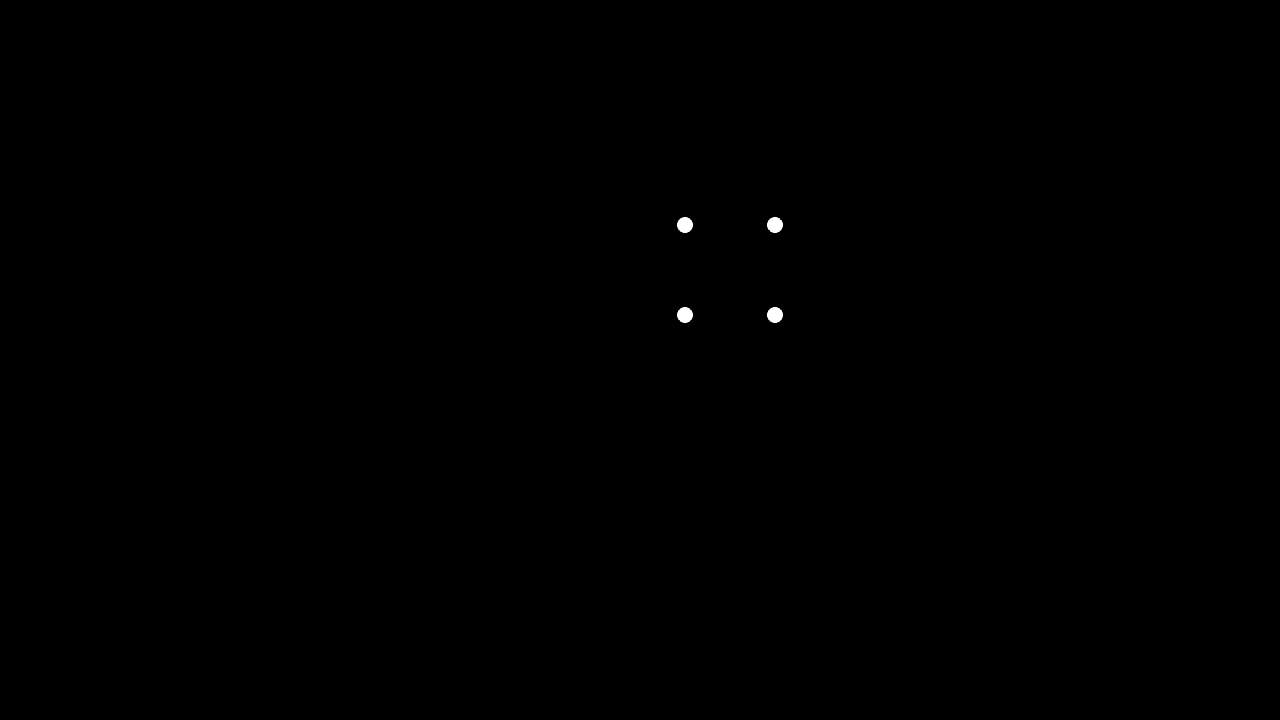

In [8]:
%%manim -qm --renderer=opengl -p SquareLattice

class SquareLattice(ThreeDScene):
    def construct(self):
        axes = ThreeDAxes()
        basis = VGroup(Dot3D([0, 0, 0]), Dot3D([1, 0, 0]), Dot3D([0, 1, 0]), Dot3D([1, 1, 0]))

        verteces = VGroup()
        for n in np.arange(-2, 2, 1):
            for k in np.arange(-2, 2, 1):
                verteces += basis.move_to([n, k, 0])
                
        print(verteces)
        #self.interactive_embed()

Manim Community v0.18.1

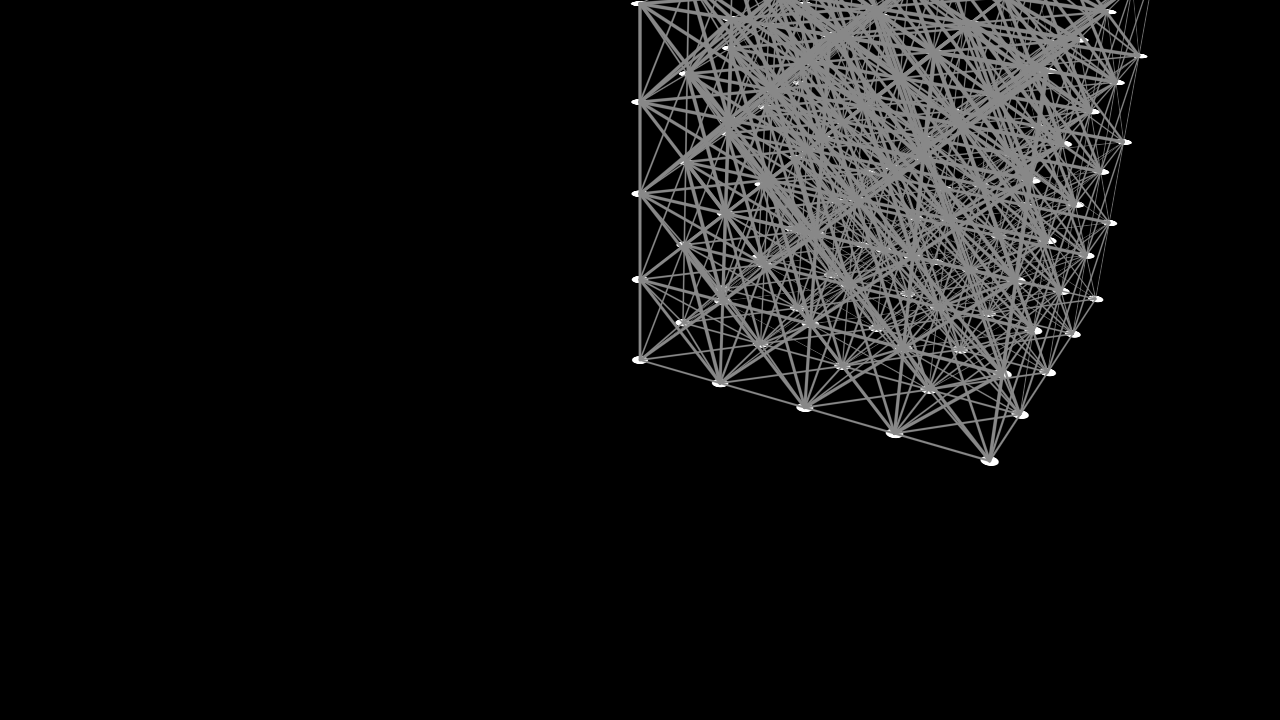

In [10]:
%%manim -qm --renderer=opengl -p DotLattice3D
import numpy as np

class DotLattice3D(ThreeDScene):
    def construct(self):
        grid_size = 5
        dot_spacing = 1

        points = []
        for x in range(grid_size):
            for y in range(grid_size):
                for z in range(grid_size):
                    point = np.array([x, y, z]) * dot_spacing
                    points.append(point)
                    self.add(Dot(point=point, color=WHITE))

        lines = []
        for i in range(len(points)):
            for j in range(i + 1, len(points)):
                diff = np.linalg.norm(points[i] - points[j])
                if diff <= np.sqrt(3) * dot_spacing + 0.001:
                    lines.append(Line(start=points[i], end=points[j], color=GRAY))
                    self.add(lines[-1])

        self.set_camera_orientation(phi=60 * DEGREES, theta=30 * DEGREES)


In [2]:
from manim import *
from manim.opengl import *
config.media_width = "80%"
config.verbosity = "WARNING"

Manim Community v0.18.1

[-3 -3  0]
[ 2 -3  0]
[-3  2  0]
[2 2 0]


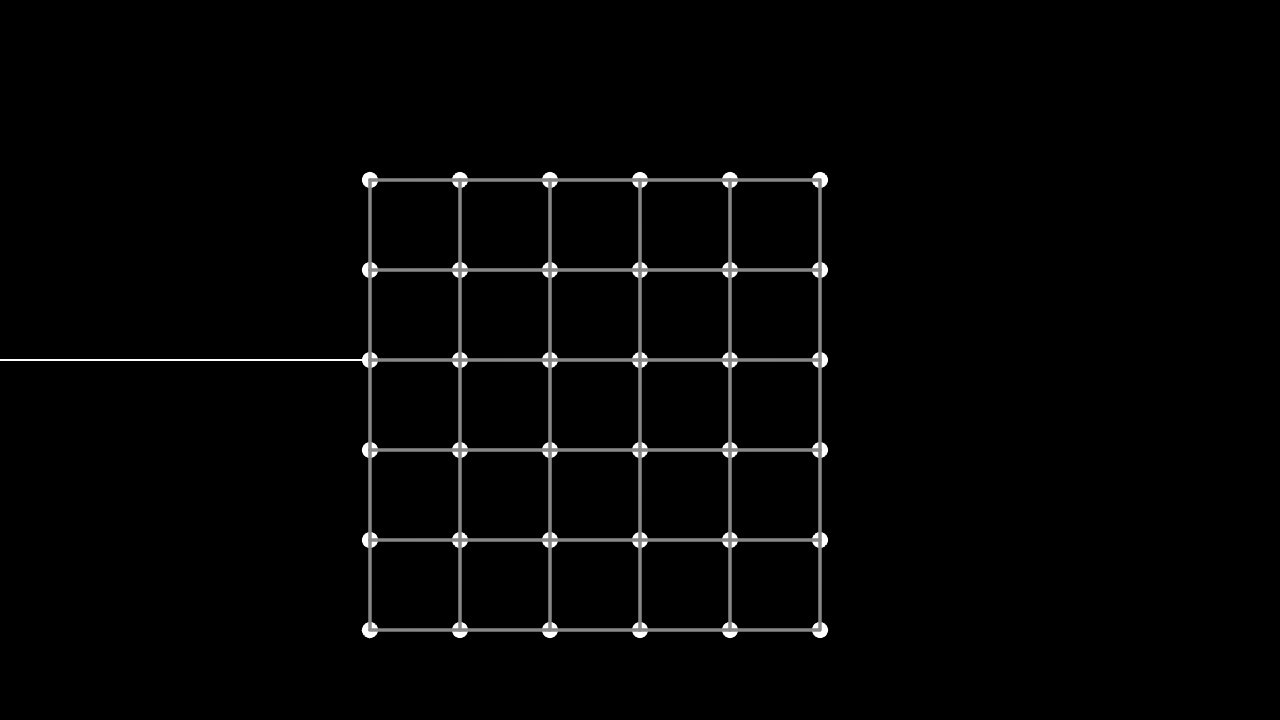

In [32]:
%%manim -qm --renderer=opengl -p DotLattice3DPlane

class DotLattice3DPlane(ThreeDScene):
    def construct(self):
        grid_size = 3
        dot_spacing = 1

        points = []
        for x in range(-grid_size, grid_size):
            for y in range(-grid_size, grid_size):
                point = np.array([x, y, 0]) * dot_spacing
                points.append(point)
                self.add(Dot3D(point=point, color=WHITE))

        points_np = np.array(points).reshape((6,6,3))
        print(points_np[0,0])
        print(points_np[5,0])
        print(points_np[0,5])
        print(points_np[5,5])

        for i in range(len(points)):
            for j in range(i + 1, len(points)):
                diff = np.linalg.norm(points[i][:2] - points[j][:2])
                if diff <= dot_spacing + 0.001:
                    self.add(Line(start=points[i], end=points[j], color=GRAY))

        #self.interactive_embed()

In [40]:
%%manim -ql --renderer=opengl --write_to_movie DotLattice3DPlane

class DotLattice3DPlane(ThreeDScene):
    def construct(self):
        N=6
        grid_size = 3
        dot_spacing = 1

        points = []
        verteces1 = VGroup()
        for x in range(-grid_size, grid_size):
            for y in range(-grid_size, grid_size):
                point = np.array([x, y, 0]) * dot_spacing
                points.append(point)
                verteces1 += Dot3D(point=point, color=WHITE)

        self.play(AnimationGroup(*[Create(vertex) for vertex in verteces1], lag_ratio=0.05))

        points_np = np.array(points).reshape((6,6,3))
        print(points_np[0,0])
        print(points_np[5,0])
        print(points_np[0,5])
        print(points_np[5,5])

        for i in range(len(points)):
            for j in range(i + 1, len(points)):
                diff = np.linalg.norm(points[i][:2] - points[j][:2])
                if diff <= dot_spacing + 0.001:
                    self.add(Line(start=points[i], end=points[j], color=GRAY))

        #self.interactive_embed()
        verteces2 = VGroup()
        for x in range(N):
            for y in range(N):
                points_np[x,y] = points_np[x,y] + 2
                verteces2 += Dot3D(point=points_np[x,y], color=WHITE)
        
        self.play(AnimationGroup(*[[Transform(vertex1, vertex2) for vertex2 in verteces2] for vertex1 in verteces1], lag_ratio=0.05))

        #self.play(AnimationGroup(*[Create(vertex) for vertex in verteces2], lag_ratio=0.05))
        

Manim Community v0.18.1

[-3 -3  0]
[ 2 -3  0]
[-3  2  0]
[2 2 0]


TypeError: object of type 'float' has no len()

In [28]:
a = np.arange(18).reshape((3, 3, 2))
a

array([[[ 0,  1],
        [ 2,  3],
        [ 4,  5]],

       [[ 6,  7],
        [ 8,  9],
        [10, 11]],

       [[12, 13],
        [14, 15],
        [16, 17]]])

In [29]:
a[0,0,0]
a[0,2,0]

4

In [1]:
from manim import *
import numpy as np




In [14]:
%%manim -qm --renderer=opengl -p DotLattice3DPlane

class DotLattice3DPlane(ThreeDScene):
    def construct(self):
        grid_size = 5
        dot_spacing = 1

        points = []
        for x in range(grid_size):
            for y in range(grid_size):
                point = np.array([x, y, 0]) * dot_spacing
                points.append(point)
                self.add(Dot3D(point=point, color=WHITE))

        lines = []
        for i in range(len(points)):
            for j in range(i + 1, len(points)):
                diff = np.linalg.norm([float(x) for x in (points[i][:2] - points[j][:2])])
                if diff <= np.sqrt(2) * dot_spacing + 0.001:
                    lines.append(Line3D(start=points[i], end=points[j], color=GRAY))
                    self.add(lines[-1])


Manim Community v0.18.1

TypeError: 'float' object is not iterable

In [41]:
%%manim -ql --renderer=opengl --write_to_movie DotLattice3DPlane

class DotLattice3DPlane(ThreeDScene):
    def construct(self):
        grid_size = 5
        dot_spacing = 1
        movement_direction = np.array([1, 1, 0])  # Movement direction in x and y

        points = []
        for x in range(grid_size):
            for y in range(grid_size):
                point = np.array([x, y, 0]) * dot_spacing
                points.append(point)
                dot = Dot3D(point=point, color=WHITE)
                self.add(dot)

        self.wait(1)  # Wait for 1 second before moving the dots

        for _ in range(30):  # Move the dots gradually
            for point, dot in zip(points, self.mobjects):
                point += movement_direction * 0.1
                dot.move_to(point)
            self.wait(0.1)

        self.wait(2)  # Wait for 2 seconds at the end


Manim Community v0.18.1

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int32') with casting rule 'same_kind'

In [42]:
%%manim -ql --renderer=opengl --write_to_movie DotLattice3DPlane

class DotLattice3DPlane(ThreeDScene):
    def construct(self):
        grid_size = 5
        dot_spacing = 1
        movement_direction = np.array([1, 1, 0])  # Movement direction in x and y

        points = []
        dots = VGroup()
        for x in range(grid_size):
            for y in range(grid_size):
                point = np.array([x, y, 0]) * dot_spacing
                points.append(point)
                dot = Dot3D(point=point, color=WHITE)
                dots.add(dot)
        self.add(dots)

        self.wait(1)  # Wait for 1 second before moving the dots

        for _ in range(30):  # Move the dots gradually
            for i, dot in enumerate(dots):
                point = points[i] + movement_direction * 0.1
                points[i] = point
                dot.move_to(point)
            self.wait(0.1)

        self.wait(2)  # Wait for 2 seconds at the end


Manim Community v0.18.1

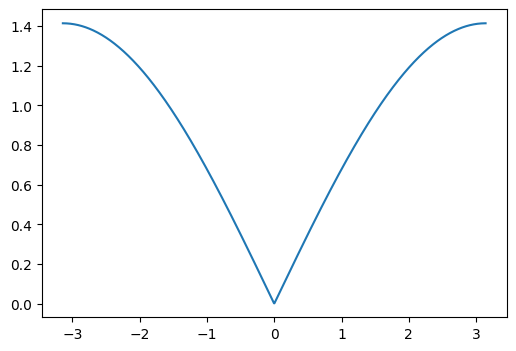

In [2]:
import sympy as smp
m = 2
c = 1
a = 1
x, y = smp.symbols('x y')
fs = smp.solve(smp.cos(x) - 1 + (m/(2*c))*y**2, y, dict=True)
f1 = smp.lambdify(x, fs[1][y])

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
ka = np.linspace(-np.pi/a, np.pi/a, 1000)
plt.plot(ka, f1(ka))


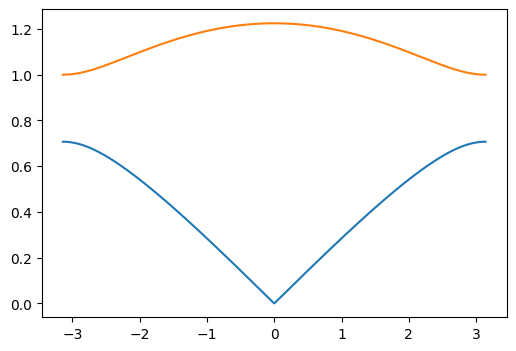

In [6]:
ma = 2
mb = 4
c = 1
a = 1
x, y = smp.symbols('x y')
fs = smp.solve(2*smp.cos(x) + 2 - (2 - (ma/c)*y**2)*(2 - (mb/c)*y**2), y, dict=True)
f1 = smp.lambdify(x, fs[1][y])
f2 = smp.lambdify(x, fs[3][y])

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
ka = np.linspace(-np.pi/a, np.pi/a, 1000)
plt.plot(ka, f1(ka))
plt.plot(ka, f2(ka))

In [1]:
from manim import *
from manim.opengl import *
config.media_width = "80%"
config.verbosity = "WARNING"

In [3]:
%%manim -qm --renderer=opengl -p NewtonIteration

class NewtonIteration(Scene):
    k = 0
    w = 0
    def construct(self):
        self.axes = Axes(x_range=(-np.pi/a, np.pi/a, np.pi/6), y_range=(-1, 2, 0.5), x_length=5, y_length=4)
        self.f = lambda x: f1(x)
        self.axes.shift(4*RIGHT)
        curve = self.axes.plot(self.f, color=RED)
        #curve.shift(5*RIGHT)
        self.cursor_dot = Dot(point=np.array([4, 0, 0]), color=YELLOW)
        self.play(Create(self.axes), Create(curve), FadeIn(self.cursor_dot))

        #------------------------------------------------------------------------------------------
        grid_size = 2
        dot_spacing = 1
        movement_direction = np.array([1, 1, 0])  # Movement direction in x and y

        points = []
        dots = VGroup()
        for x in range(-2*grid_size, 0):
            for y in range(-grid_size, grid_size):
                point = np.array([x, y, 0]) * dot_spacing
                points.append(point)
                dot = Dot3D(point=point, color=WHITE)
                dots.add(dot)
        self.add(dots)

        # self.wait(1)  # Wait for 1 second before moving the dots

        # for _ in range(30):  # Move the dots gradually
        #     for i, dot in enumerate(dots):
        #         point = points[i] + movement_direction * 0.1
        #         points[i] = point
        #         dot.move_to(point)
        #     self.wait(0.1)




        #------------------------------------------------------------------------------------------
 
        self.interactive_embed()


    def on_key_press(self, symbol, modifiers):
        from pyglet.window import key as pyglet_key
        
        if symbol == pyglet_key.P:
            x, y = self.axes.point_to_coords(self.mouse_point.get_center())
            #text = MarkupText(f'[{x}, {self.f(x)}]', font_size=8, color=WHITE)
            #text.shift((4*RIGHT, 3*UP))
            self.play(#Create(text),
                self.cursor_dot.animate.move_to(self.axes.c2p(x, self.f(x)))
            )
            # k = x
            # w = self.f(x)
            # print(k, w)
            

        # if symbol == pyglet_key.I:
        #     x, y = self.axes.point_to_coords(self.cursor_dot.get_center())
        #     # Newton iteration: x_new = x - f(x) / f'(x)
        #     x_new = x - self.f(x) / derivative(self.f, x, dx=0.01)
        #     curve_point = self.cursor_dot.get_center()
        #     axes_point = self.axes.c2p(x_new, 0)
        #     tangent = Line(
        #         curve_point + (curve_point - axes_point)*0.25,
        #         axes_point + (axes_point - curve_point)*0.25,
        #         color=YELLOW,
        #         stroke_width=2,
        #     )
        #     self.play(Create(tangent))
        #     self.play(self.cursor_dot.animate.move_to(self.axes.c2p(x_new, 0)))
        #     self.play(
        #         self.cursor_dot.animate.move_to(self.axes.c2p(x_new, self.f(x_new))),
        #         FadeOut(tangent)
        #     )
        
        super().on_key_press(symbol, modifiers)

Manim Community v0.18.1

Python 3.11.2 (tags/v3.11.2:878ead1, Feb  7 2023, 16:38:35) [MSC v.1934 64 bit (AMD64)]
Type 'copyright', 'credits' or 'license' for more information
IPython 8.0.1 -- An enhanced Interactive Python. Type '?' for help.



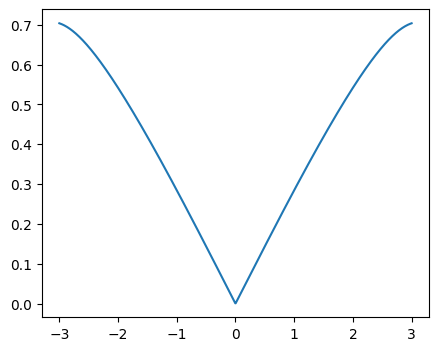

In [11]:
def f(x):
    return 0.866025403784439*np.sqrt(1 - 0.74535599249993*np.sqrt(0.8*np.cos(x) + 1))

xx = np.linspace(-3, 3, 1000)

plt.figure(figsize=(5,4))
plt.plot(xx, f(xx))


In [9]:
s = 3
print(f'AADF {s}')

AADF 3


Manim Community v0.18.1

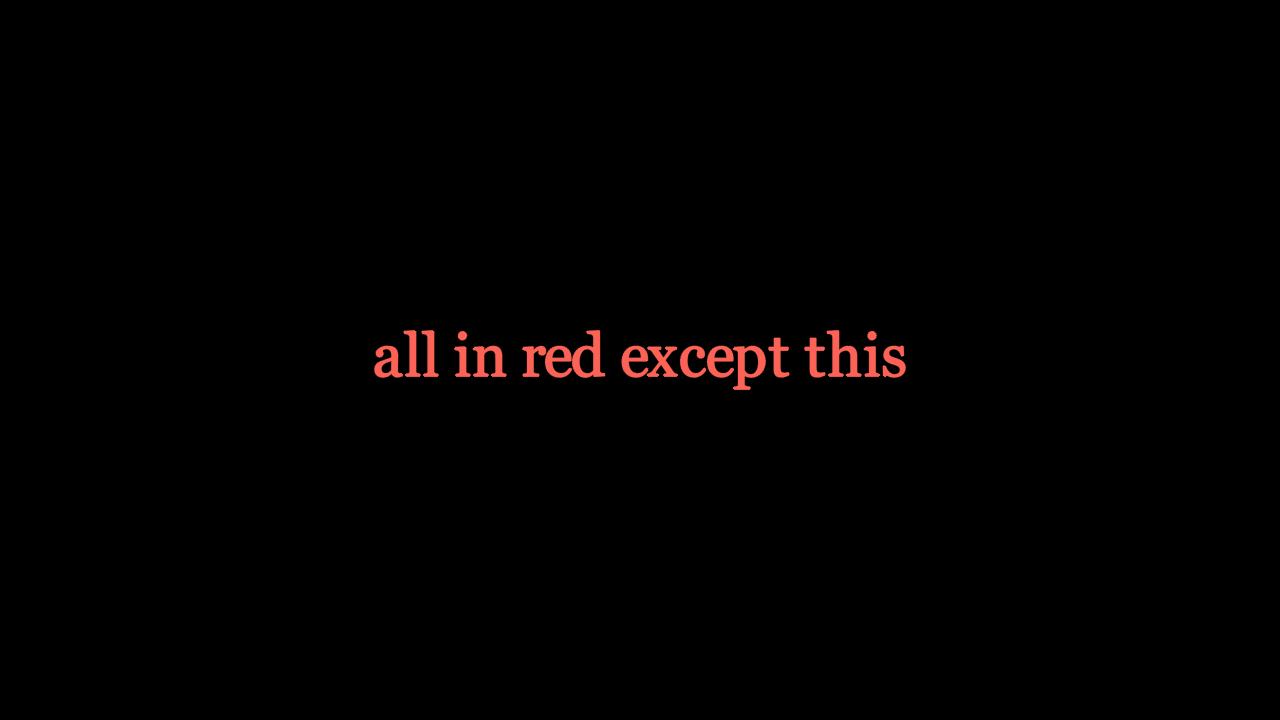

In [16]:
%%manim -qm --renderer=opengl --write_to_movie SingleLineColor

class SingleLineColor(Scene):
    def construct(self):
        text = MarkupText(
            f'all in red except this', color=RED
        )
        self.add(text)



# don't remove below command for run button to work
#%manim -qm -v WARNING SingleLineColor